# Система машинного перевода

## EDA

я буду использовать корпус русско-английских предложений с tatoeba

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
names = ["number_of_russian_sentense", "russian_sentense", "number_of_english_sentense", "english_sentense"]
data = pd.read_csv("Sentence pairs in Russian-English - 2026-06-27.tsv", sep="\t", on_bad_lines="skip", names=names)
data

,number_of_russian_sentense,russian_sentense,number_of_english_sentense,english_sentense
0,243,Один раз в жизни я делаю хорошее дело... И оно...,3257,For once in my life I'm doing a good deed... A...
1,5409,Давайте что-нибудь попробуем!,1276,Let's try something.
2,5410,Мне пора идти спать.,1277,I have to go to sleep.
3,5411,Что ты делаешь?,16492,What are you doing?
4,5411,Что ты делаешь?,511884,What do you make?
...,...,...,...,...
819765,13265271,У неё не меньше трёхсот книг.,13956498,She has at least three hundred books.
819766,2832432,Мне нужно поговорить с вами двумя.,2387749,I need to talk to both of you.
819767,8500353,Том пригласил меня к себе домой.,13956499,Tom invited me over to his house.
819768,4519726,"Как он смог понять, что я говорю?",10113902,How could he understand what I said?


In [83]:
#unique data check
print(f"russian: {data["number_of_russian_sentense"].unique().size} | english: {data["number_of_english_sentense"].unique().size}")

russian: 703080 | english: 539665


очевидно, в файлах есть дубликаты, это нормлаьно ибо перводы одного предложения могут быть различными, часто это зависит от контекста; \
так же частво встречается повторы связанные с ты | вы в русском, которые перводятся одинаково на английский

в целом, я бегло посмотрел пару десятков переводов - они корректные

In [84]:
#space check
print(f"russian: {data["number_of_russian_sentense"].isna().sum()} | english: {data["number_of_english_sentense"].isna().sum()}")

russian: 0 | english: 0


In [85]:
#average len of sentense check
print("symbols")
print(f"russian: {data["russian_sentense"].str.len().mean()} | english: {data["english_sentense"].str.len().mean()}")

print("\nwords")
print(f"russian: {data["russian_sentense"].str.split().str.len().mean()} | english: {data["english_sentense"].str.split().str.len().mean()}")

symbols
russian: 30.7748770996743 | english: 31.34188613879503

words
russian: 5.3650682508508485 | english: 6.267605547897581


{'whiskers': [<matplotlib.lines.Line2D at 0x7f9ea7f4dbe0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f9ea7f4de80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f9ea7f4da90>],
 'medians': [<matplotlib.lines.Line2D at 0x7f9ea7f4e120>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f9ea7f4e270>],
 'means': []}

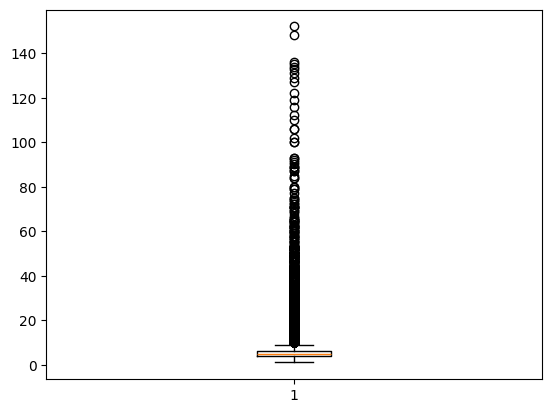

In [86]:
plt.boxplot(data["russian_sentense"].str.split().str.len())

{'whiskers': [<matplotlib.lines.Line2D at 0x7f9ea1ed5940>,
 'caps': [<matplotlib.lines.Line2D at 0x7f9ea1ed5be0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f9ea1ed57f0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f9ea1ed5e80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f9ea1ed5fd0>],
 'means': []}

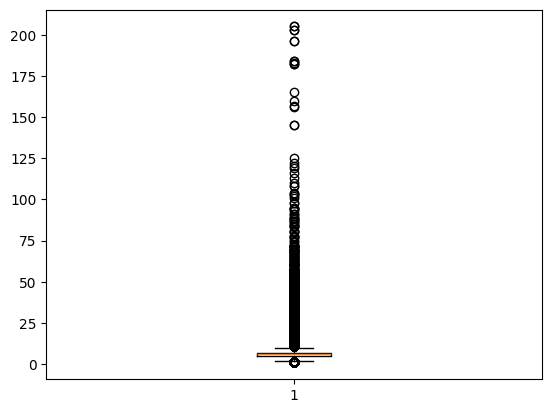

In [87]:
plt.boxplot(data["english_sentense"].str.split().str.len())

In [88]:
russian_word_counts = data["russian_sentense"].str.split().str.len()

Q1 = russian_word_counts.quantile(0.25)
Q3 = russian_word_counts.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = russian_word_counts[(russian_word_counts < lower) | (russian_word_counts > upper)]
count = len(outliers)
print(f"Outlier in russian: {count}")

Outlier in russian: 37405


In [89]:
english_word_counts = data["english_sentense"].str.split().str.len()

Q1 = english_word_counts.quantile(0.25)
Q3 = english_word_counts.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = english_word_counts[(english_word_counts < lower) | (english_word_counts > upper)]
count = len(outliers)
print(f"Outlier in englisg: {count}")

Outlier in englisg: 43457


In [90]:
russian_word_counts.quantile(0.999)

np.float64(26.0)

In [91]:
english_word_counts.quantile(0.999)

np.float64(30.0)

In [92]:
with pd.option_context('display.max_colwidth', None):
    print(data["russian_sentense"].loc[russian_word_counts.nlargest(5).index])
    print()
    print(data["english_sentense"].loc[english_word_counts.nlargest(5).index])

608505                   Я жид. Да разве у жида нет глаз? Разве у жида нет рук, органов, членов тела, чувств, привязанностей, страстей? Разве не та же самая пища насыщает его, разве не то же оружие ранит его, разве он не подвержен тем же недугам, разве не те же лекарства исцеляют его, разве не согревают и не студят его те же лето и зима, как и христианина? Если нас уколоть — разве у нас не идет кровь? Если нас пощекотать — разве мы не смеемся? Если нас отравить — разве мы не умираем? А если нас оскорбляют — разве мы не должны мстить? Если мы во всем похожи на вас, то мы хотим походить и в этом. Если жид обидит христианина, что тому внушает его смирение? Месть! Если христианин обидит жида, каково должно быть его терпение по христианскому примеру? Тоже месть! Вы нас учите гнусности — я ее исполню. Уж поверьте, что я превзойду своих учителей!
608506    Я еврей. Да разве у еврея нет глаз? Разве у еврея нет рук, внутренних органов, частей тела, чувств, привязанностей, страстей? Разве не та 

думаю, стоит обрезать по 99.9 квантилю, где максимум будет 30 слов в предлжении, ибо данных для обучения на длинные тексты просто очень мало и в них нет никакого смысла

In [93]:
print(data["russian_sentense"].loc[russian_word_counts.nsmallest(5).index])
print()
print(data["english_sentense"].loc[english_word_counts.nsmallest(5).index])

395           Войдите!
396           Войдите!
397           Войдите!
400    Поторапливайся!
449           Холодно.
Name: russian_sentense, dtype: object

78                  So?
191    Congratulations!
397              Enter!
398            Welcome.
558                Wow!
Name: english_sentense, dtype: object


In [94]:
#unique words count
print(f"russian: {len(data["russian_sentense"].str.split().explode().unique())} | english: {len(data["english_sentense"].str.split().explode().unique())}")

russian: 184475 | english: 75145
